# 02 — Exploratory data analysis

Class balance, feature distributions, correlation structure, and which single features separate benign traffic from attacks.

**Pipeline module:** `src/eda.py`

*Every number and figure below was produced by the pipeline in `src/`. This
notebook reads those results; it does not re-implement them.*

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import Image, display

TABLES = ROOT / "results" / "tables"
FIGURES = ROOT / "results" / "figures"

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

def table(name, **kw):
    """Read one of the pipeline's result tables."""
    return pd.read_csv(TABLES / name, **kw)

def figure(name):
    """Display one of the pipeline's figures."""
    return Image(filename=str(FIGURES / name))

print(f"project root: {ROOT}")

project root: C:\Users\babu\OneDrive\Desktop\ML Project


## Class distribution after cleaning

A logarithmic axis is unavoidable here. On a linear scale every class below DoS would
be an invisible sliver against BENIGN's 2,072,444 rows.

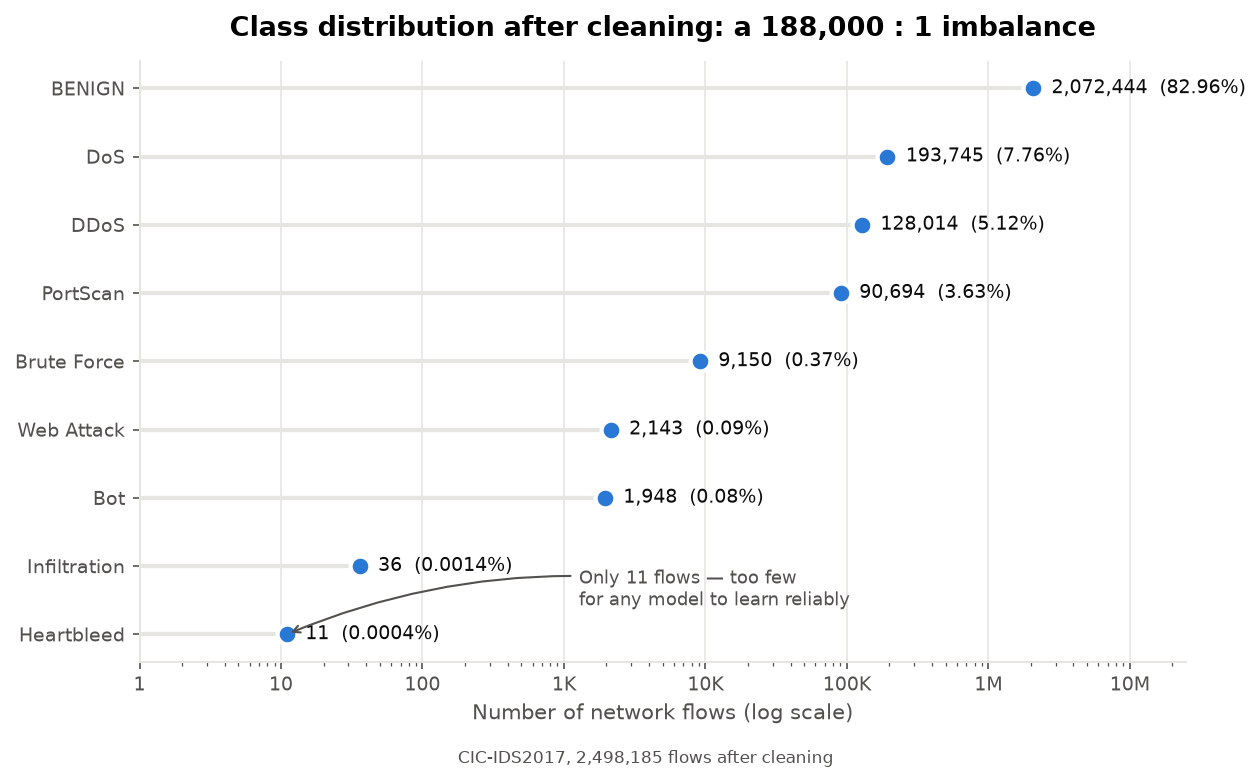

In [2]:
figure("01_class_distribution_multiclass.png")

In [3]:
clean_counts = table("class_distribution_clean.csv", index_col=0)
clean_counts["percent"] = (clean_counts["count"] / clean_counts["count"].sum() * 100).round(4)
clean_counts

,count,percent
Label_grouped,,
BENIGN,2072444,82.9580
DoS,193745,7.7554
DDoS,128014,5.1243
PortScan,90694,3.6304
Brute Force,9150,0.3663
Web Attack,2143,0.0858
Bot,1948,0.0780
Infiltration,36,0.0014
Heartbleed,11,0.0004


## The binary target

82.96% of flows are benign. A model that predicts "BENIGN" for everything therefore
scores **82.96% accuracy while detecting nothing** — which is why this project reports
precision, recall, F1 and PR-AUC rather than accuracy alone.

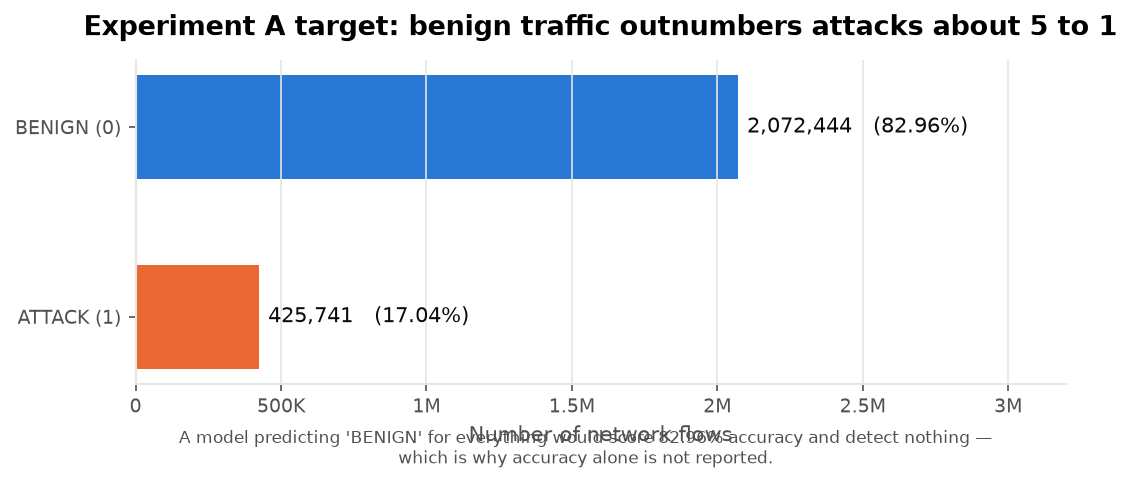

In [4]:
figure("02_class_distribution_binary.png")

## Correlation structure

Two large blocks are visible: a packet-size cluster and a timing (inter-arrival)
cluster. Features inside each block carry nearly the same information — `Avg Bwd
Segment Size` and `Bwd Packet Length Mean` correlate at almost 1.0 because they are
the same quantity computed twice. This is the evidence for the feature selection in
notebook 03.

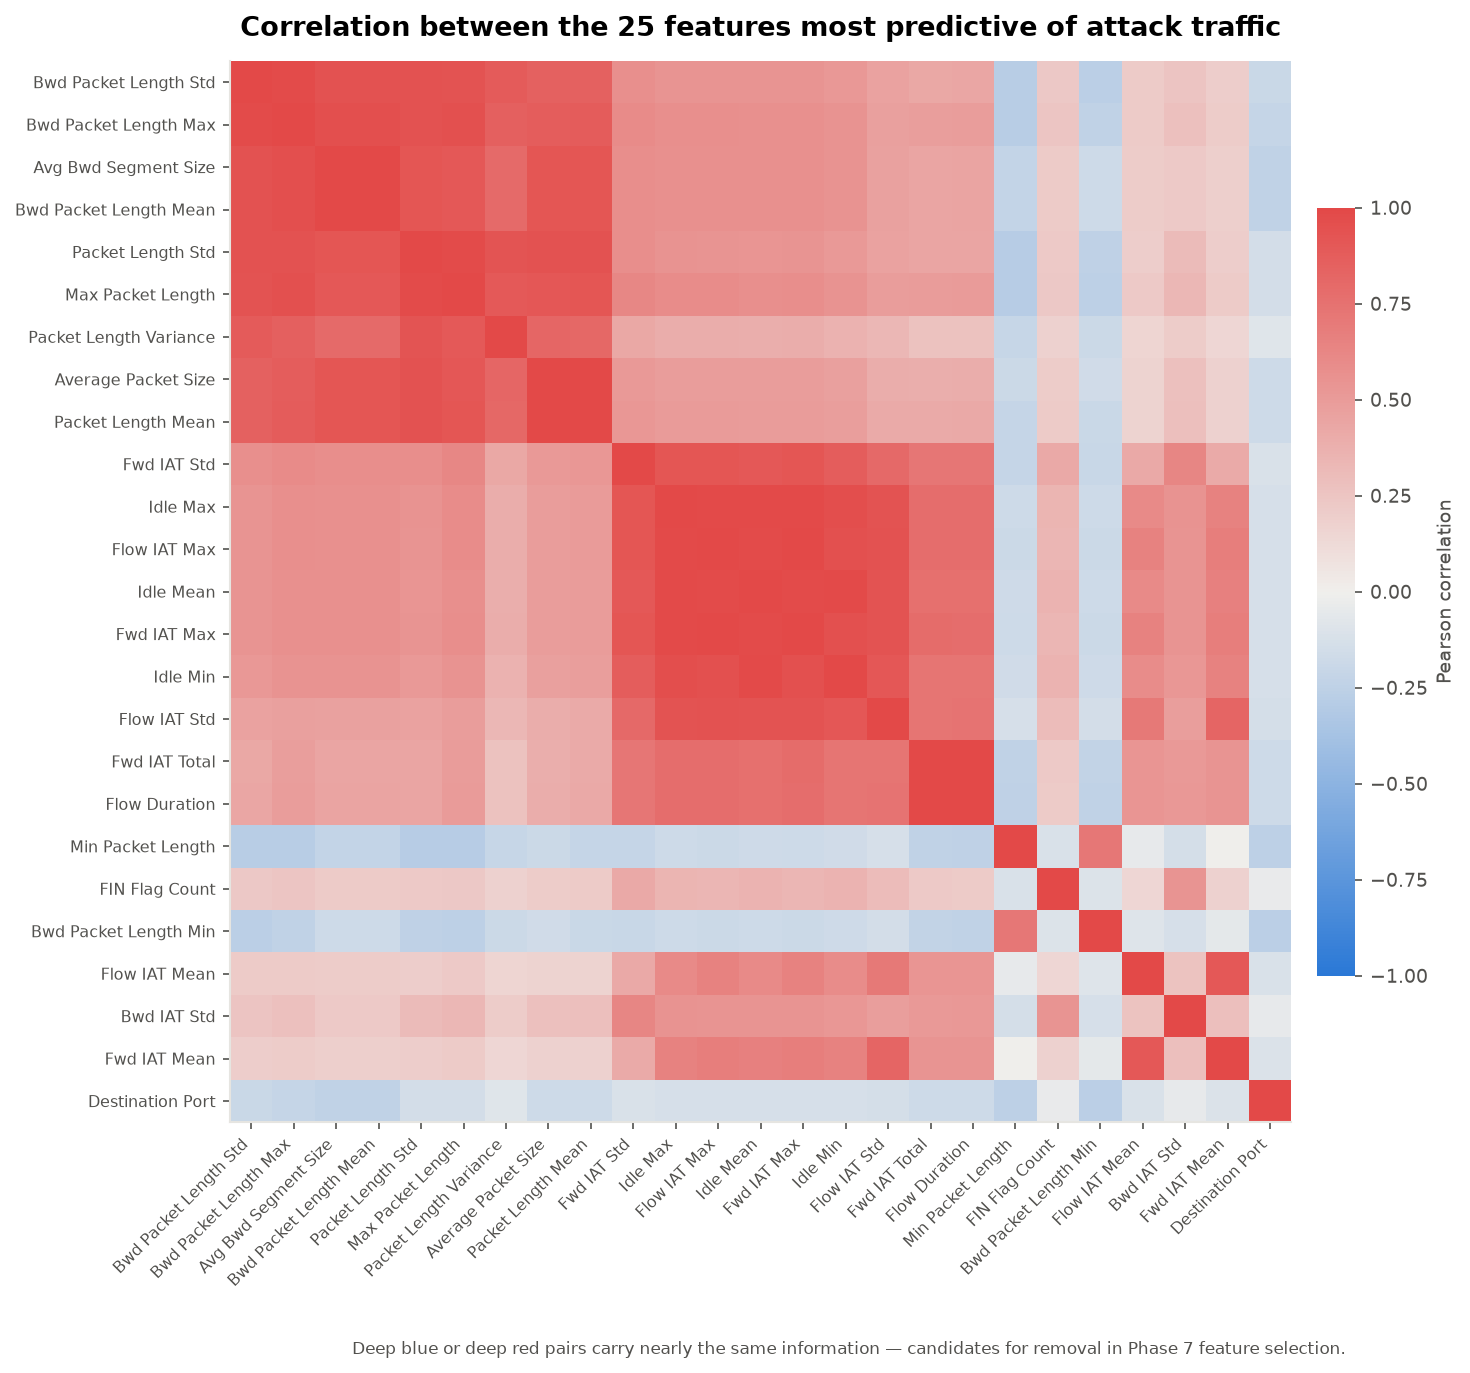

In [5]:
figure("03_correlation_heatmap.png")

## Which features separate attacks from benign traffic

In [6]:
corr = table("feature_target_correlation.csv", index_col=0)
corr.head(12).round(4)

,abs_correlation_with_attack
Bwd Packet Length Std,0.6110
Bwd Packet Length Max,0.5957
Avg Bwd Segment Size,0.5937
Bwd Packet Length Mean,0.5937
Packet Length Std,0.5727
Max Packet Length,0.5546
Packet Length Variance,0.5362
Average Packet Size,0.5208
Packet Length Mean,0.5201
Fwd IAT Std,0.5054


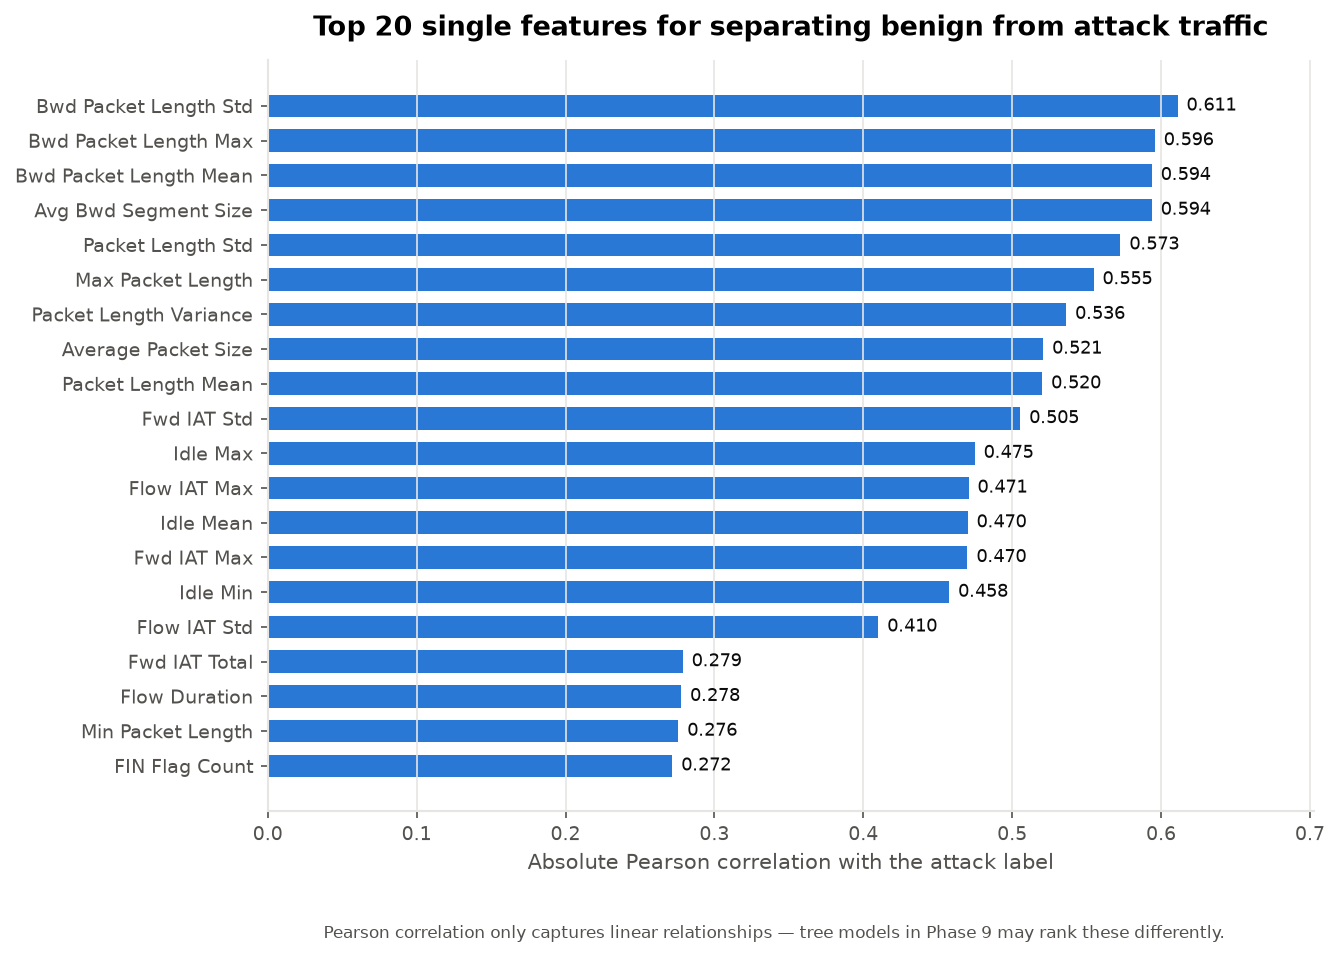

In [7]:
figure("05_feature_separation.png")

## Distributions, benign vs attack

The separation is real but not clean. Attack traffic spikes at the far right of
`Flow Duration` and `Flow IAT Mean` where benign traffic is thin — but the two
overlap heavily in the middle, which is why a threshold rule is not enough and a
model is needed.

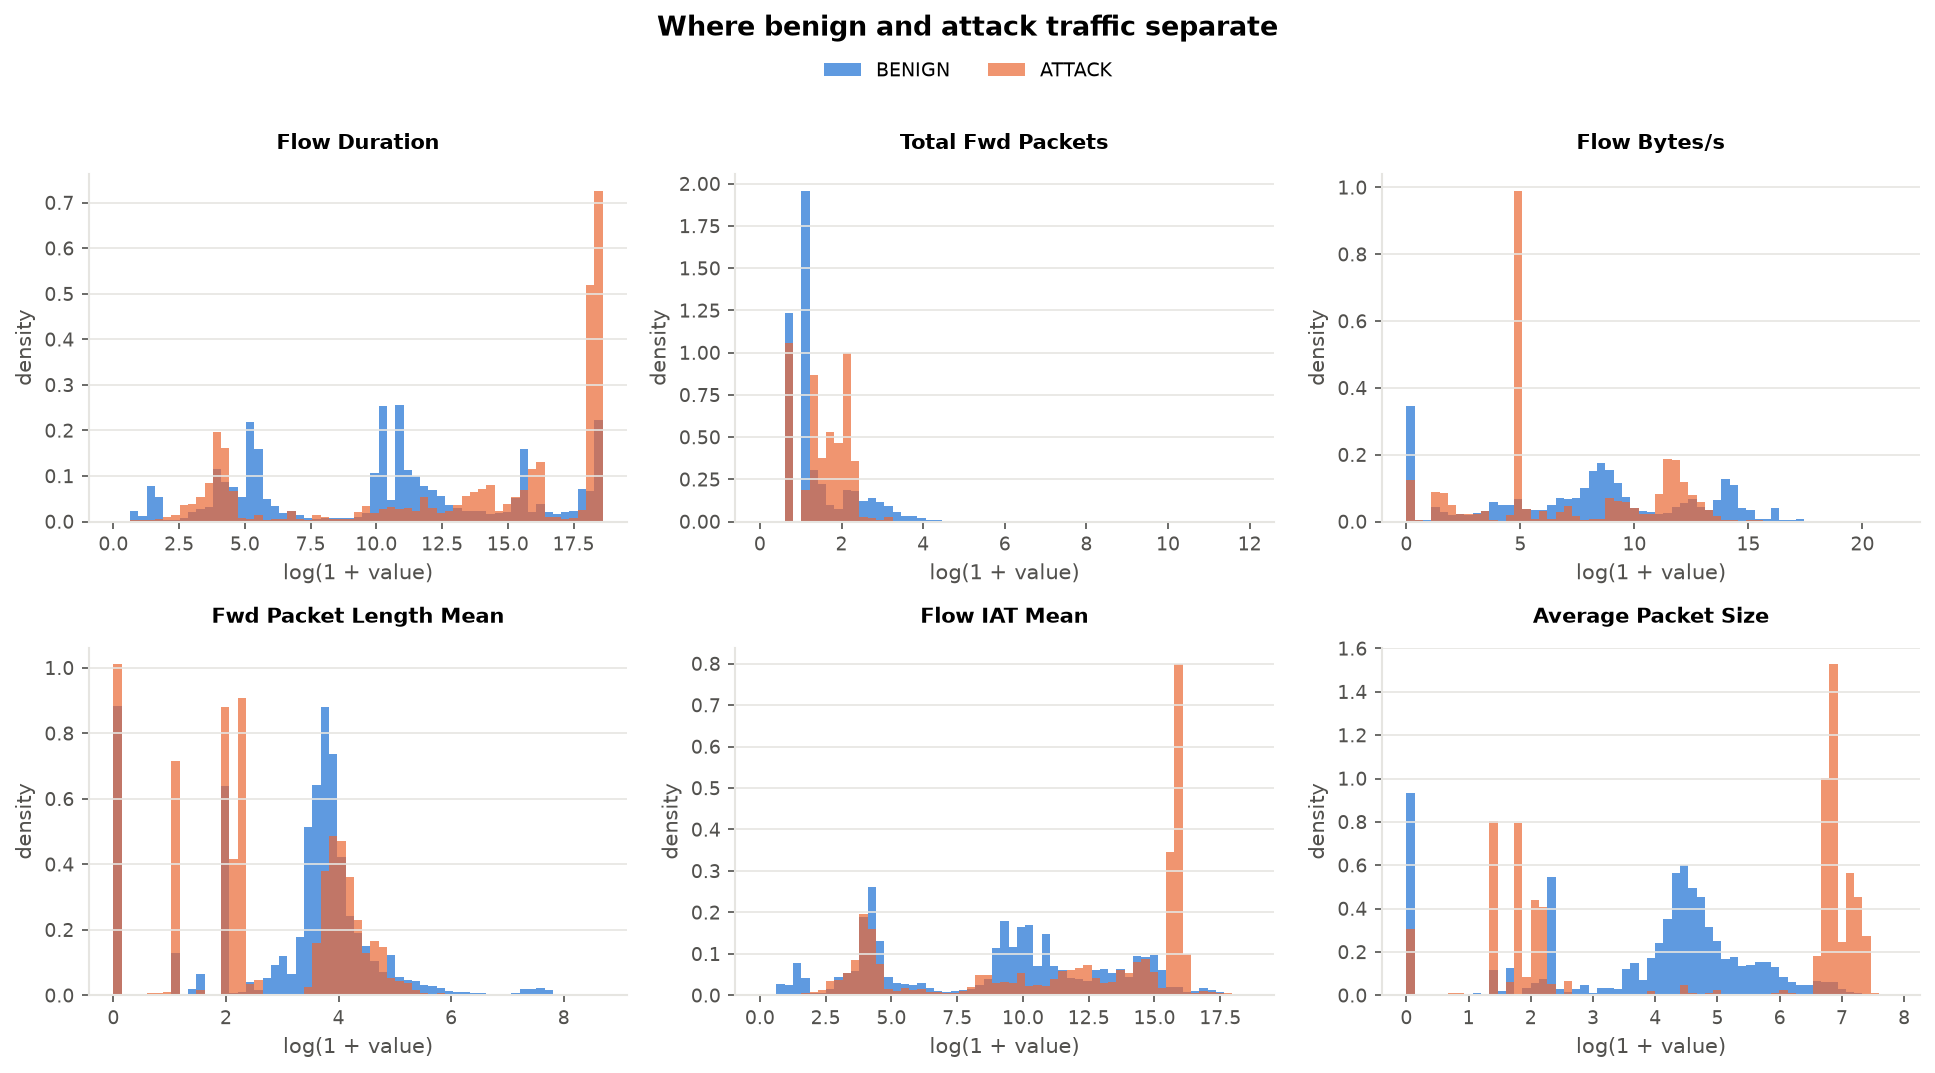

In [8]:
figure("04_feature_distributions.png")